# Analyzing River Thames Water Levels

Time-series analysis of ~115,000 tidal water-level readings for the River Thames at
London Bridge, 1911-1995: typical high- and low-tide levels, and how the share of
days with very high tides has developed over the decades.

*Based on a DataCamp guided project; code tidied and visualizations added. Data provided
with the project (station 10-11, London Bridge).*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

def IQR(column):
    """Interquartile range (IQR) of a DataFrame column."""
    q25, q75 = column.quantile([0.25, 0.75])
    return q75 - q25

# Import the London Bridge station data
df = pd.read_csv('data/10-11_London_Bridge.txt')

# Drop the unused column and give the remaining columns meaningful names
df = df.drop(columns=' HW=1 or LW=0')
df = df.rename(columns={'Date and time': 'datetime',
                        ' water level (m ODN)': 'water_level',
                        ' flag': 'flag'})
print(f"Readings loaded: {len(df)}")

Readings loaded: 115503


In [2]:
# Prepare columns for analysis
df['datetime'] = pd.to_datetime(df['datetime'], format='%d/%m/%Y %H:%M:%S')
df['year'] = df['datetime'].dt.year
df['water_level'] = df['water_level'].astype(float)
print(f"Period covered: {df['year'].min()}-{df['year'].max()}")

Period covered: 1911-1995


In [3]:
# Separate high-tide (flag = 1) and low-tide (flag = 0) readings
tide_high = df[df['flag'] == 1]
tide_low = df[df['flag'] == 0]

# Summary statistics for high and low tide
high_statistics = tide_high['water_level'].agg(['mean', 'median', IQR]).round(3)
low_statistics = tide_low['water_level'].agg(['mean', 'median', IQR]).round(3)
print("High tide (m ODN):")
print(high_statistics)
print()
print("Low tide (m ODN):")
print(low_statistics)

High tide (m ODN):
mean      3.318
median    3.353
IQR       0.744
Name: water_level, dtype: float64

Low tide (m ODN):
mean     -2.384
median   -2.413
IQR       0.538
Name: water_level, dtype: float64


## Are very high tides becoming more common?

In [4]:
# Annual share of high-tide days above the 90th percentile ("very high")
all_high_days = tide_high.groupby('year')['water_level'].count()
thres_very_high = tide_high['water_level'].quantile(0.9)
very_high_days = tide_high[tide_high['water_level'] > thres_very_high].groupby('year')['water_level'].count()
very_high_ratio = (very_high_days / all_high_days).reset_index()

# Annual share of low-tide days below the 10th percentile ("very low")
all_low_days = tide_low.groupby('year')['water_level'].count()
thres_very_low = tide_low['water_level'].quantile(0.1)
very_low_days = tide_low[tide_low['water_level'] < thres_very_low].groupby('year')['water_level'].count()
very_low_ratio = (very_low_days / all_low_days).reset_index()

print(f"'Very high' threshold: {thres_very_high:.2f} m ODN")
print(f"'Very low' threshold: {thres_very_low:.2f} m ODN")

'Very high' threshold: 3.96 m ODN
'Very low' threshold: -2.87 m ODN


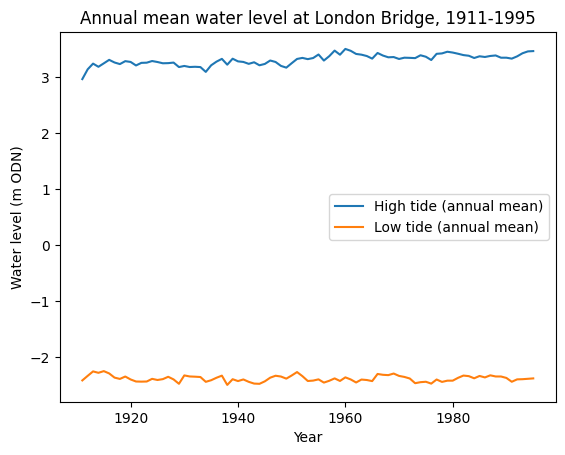

In [5]:
# Visualize the annual mean high- and low-tide levels
fig, ax = plt.subplots()
tide_high.groupby('year')['water_level'].mean().plot(ax=ax, label='High tide (annual mean)')
tide_low.groupby('year')['water_level'].mean().plot(ax=ax, label='Low tide (annual mean)')
ax.set_title("Annual mean water level at London Bridge, 1911-1995")
ax.set_xlabel("Year")
ax.set_ylabel("Water level (m ODN)")
ax.legend()
plt.show()

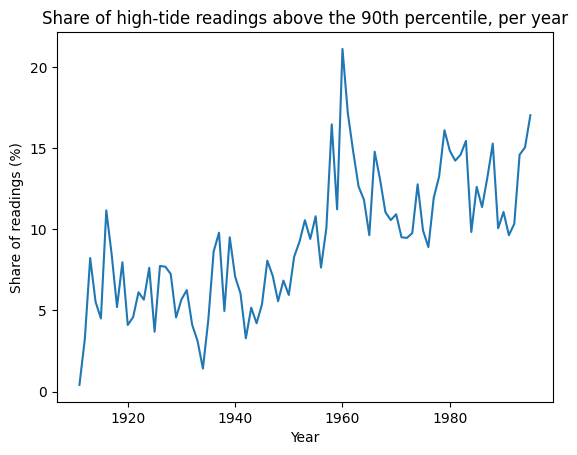

In [6]:
# Visualize the share of very high tide days per year
fig, ax = plt.subplots()
ax.plot(very_high_ratio['year'], very_high_ratio['water_level'] * 100)
ax.set_title("Share of high-tide readings above the 90th percentile, per year")
ax.set_xlabel("Year")
ax.set_ylabel("Share of readings (%)")
plt.show()

### Key observations

- Over 1911-1995, high tides at London Bridge averaged 3.32 m ODN (median 3.35, IQR 0.74) and low tides -2.38 m ODN (median -2.41, IQR 0.54).
- The share of "very high" tide readings (above the 90th percentile, 3.96 m) has risen markedly: roughly 6% of readings in the first decade of the record versus roughly 13% in the last decade.
- Annual mean high-tide levels trend visibly upward across the record, while low tides have fallen - the tidal range at London Bridge has widened over the century.